Cell 1: Global Setup & Workspace

In [1]:
# ==============================================================================
# CELL 1: SETUP & PATHS
# Defines the specific video and sets up the workspace. No loops.
# ==============================================================================
import os
import glob
import cv2
import pandas as pd
import numpy as np
import json
import deeplabcut
import ruamel.yaml
import tensorflow as tf

# Help prevent memory fragmentation during heavy ResNet-50 training
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
VIDEO_PATH = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4'

PROJECT_NAME = 'EagleRay_Top'

# --- EAGLE RAY 5-POINT SETUP ---
BODYPARTS = ['Snout', 'LeftWingtip', 'RightWingtip', 'TailBase', 'TailTip'] 

# Verify the file actually exists
if not os.path.exists(VIDEO_PATH):
    print(f"🛑 ERROR: Cannot find video at {VIDEO_PATH}")
else:
    print(f"✅ Target Locked: {os.path.basename(VIDEO_PATH)}")

2026-04-08 10:08:43.160037: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 10:08:43.191257: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 10:08:43.662126: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Target Locked: Fem1_releasedtp_20260401_GX010181.MP4


Cell 2: Standard Project Init & Offset Extraction

In [2]:
# ==============================================================================
# CELL 2: INIT PROJECT & EXTRACT FRAMES (WITH 60s OFFSET)
# Creates the project using ResNet-50 and skips the distorted intro.
# ==============================================================================
print(f"\n⚙️ Init Base Project for {PROJECT_NAME}...")
base_cfg_path = deeplabcut.create_new_project(
    f'{PROJECT_NAME}_Base', 'Dev', [VIDEO_PATH], 
    working_directory=WORKING_DIR, copy_videos=False
)

ryaml = ruamel.yaml.YAML(); ryaml.preserve_quotes = True
with open(base_cfg_path, 'r') as f: cfg = ryaml.load(f)

cfg['bodyparts'] = BODYPARTS

# --- EAGLE RAY RADIAL SKELETON ---
cfg['skeleton'] = [
    ['Snout', 'LeftWingtip'], 
    ['Snout', 'RightWingtip'], 
    ['Snout', 'TailBase'], 
    ['TailBase', 'TailTip']
]

cfg['default_net_type'] = 'resnet_50' # Standard heavy model
cfg['project_path'] = os.path.dirname(base_cfg_path)
cfg['numframes2pick'] = 40 # Increased to 40 for a robust base model

# ==============================================================================
# ⚠️ TEMPORAL OFFSET INJECTION: SKIP FIRST 60 SECONDS
# Calculates what fraction of the video 60 seconds represents and starts 
# extraction from there to avoid distorted intro frames.
# REMOVE THIS BLOCK FOR FUTURE VIDEOS IF NOT NEEDED.
# ==============================================================================
print("⏱️ Calculating frame offset to skip the first 1 minute...")
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
cap.release()

frames_to_skip = 60.0 * fps # 60 seconds
start_fraction = frames_to_skip / total_frames

if start_fraction < 1.0:
    cfg['start'] = float(start_fraction)
    print(f"   -> Skipping first 60s. Setting extraction start fraction to: {start_fraction:.4f}")
else:
    print("   -> Video is shorter than 60s. Extracting from beginning.")
# ==============================================================================

with open(base_cfg_path, 'w') as f: ryaml.dump(cfg, f)

print(f"📸 Extracting 40 frames...")
deeplabcut.extract_frames(base_cfg_path, mode='automatic', algo='kmeans', userfeedback=False)

print("\n👉 GO TO LABEL STUDIO: Label these 40 frames. Export the CSV.")


⚙️ Init Base Project for EagleRay_Top...
Created "/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/videos"
Created "/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/labeled-data"
Created "/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/training-datasets"
Created "/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4 to /mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/videos/Fem1_releasedtp_20260401_GX010181.MP4
/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/videos/Fem1_releasedtp_20260401_GX010181.MP4
Generated "/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/config.yaml"

A new pr

10831it [06:22, 28.28it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).

👉 GO TO LABEL STUDIO: Label these 40 frames. Export the CSV.


Cell 3: Train Standard Pipeline & Verify

In [ ]:
# ==============================================================================
# CELL 3: DATA-SAFE BASE MODEL TRAINING (GOLDEN PARSER + FILE MAPPING)
# ==============================================================================
import os
import glob
import pandas as pd
import numpy as np
import json
import yaml
import tensorflow as tf
import deeplabcut

# --- 1. GLOBALS & PATHS ---
WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
VIDEO_PATH = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4'
PROJECT_NAME = 'EagleRay_Top'
BODYPARTS = ['Snout', 'LeftWingtip', 'RightWingtip', 'TailBase', 'TailTip'] 
CSV_EXPORT = '/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/labeled-data/Fem1_releasedtp_20260401_GX010181/project-16-at-2026-04-08-12-53-79818071.csv'

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# --- 2. RECOVER PROJECT & GET EXACT SCORER ---
found_projects = glob.glob(os.path.join(WORKING_DIR, f'{PROJECT_NAME}_Base-Dev-*', 'config.yaml'))
if not found_projects: raise FileNotFoundError("❌ Project config not found.")
base_cfg_path = found_projects[0]
proj_dir = os.path.dirname(base_cfg_path)
video_folder = os.path.splitext(os.path.basename(VIDEO_PATH))[0]

with open(base_cfg_path, 'r') as f:
    cfg = yaml.safe_load(f)
exact_scorer = cfg.get('scorer', 'Dev')

# --- 3. DYNAMIC PARSER & FILE MAPPER ---
print("⚙️ Parsing Label Studio CSV and mapping physical files...")

actual_img_dir = os.path.join(proj_dir, 'labeled-data', video_folder)
physical_files = os.listdir(actual_img_dir) if os.path.exists(actual_img_dir) else []
# Map the integer frame number directly to the exact physical filename string
file_map = {int(''.join(filter(str.isdigit, f))): f for f in physical_files if f.startswith('img') and f.endswith('.png')}

df_ls = pd.read_csv(CSV_EXPORT)

# Dynamic column detection
json_col = next((col for col in ['label', 'annotation', 'keypointlabels'] if col in df_ls.columns), None)
if not json_col:
    raise ValueError(f"❌ Could not find JSON column in CSV. Found headers: {list(df_ls.columns)}")

data_dict = {}
valid_points_found = 0

for idx, row in df_ls.iterrows():
    labels_str = row.get(json_col, '')
    img_path_raw = str(row.get('image', ''))
    
    # Extract raw filename and get exact physical match from disk
    fname_raw = os.path.basename(img_path_raw).split('-')[-1] if '-' in img_path_raw else os.path.basename(img_path_raw)
    frame_num = int(''.join(filter(str.isdigit, fname_raw)))
    fname = file_map.get(frame_num, fname_raw)
        
    rel_path = f"labeled-data/{video_folder}/{fname}"
    
    frame_data = {'image': rel_path}
    for bp in BODYPARTS:
        frame_data[f'{bp}_x'] = np.nan
        frame_data[f'{bp}_y'] = np.nan
        
    if pd.notna(labels_str) and isinstance(labels_str, str):
        try:
            labels = json.loads(labels_str)
            if isinstance(labels, list) and len(labels) > 0 and 'result' in labels[0]:
                labels = labels[0]['result']
                
            for label in labels:
                val = label.get('value', label) 
                
                if 'keypointlabels' in val and len(val['keypointlabels']) > 0:
                    bp = val['keypointlabels'][0]
                    if bp in BODYPARTS:
                        w = val.get('original_width', 3840)
                        h = val.get('original_height', 2160)
                        frame_data[f'{bp}_x'] = (val['x'] * w) / 100.0
                        frame_data[f'{bp}_y'] = (val['y'] * h) / 100.0
                        valid_points_found += 1
        except json.JSONDecodeError:
            pass
            
    if video_folder not in data_dict:
        data_dict[video_folder] = []
    data_dict[video_folder].append(frame_data)

print(f"📊 Extracted {len(data_dict.get(video_folder, []))} rows. Total valid coordinates found: {valid_points_found}")
if valid_points_found == 0:
    raise ValueError("❌ PARSER FAILURE: Zero valid coordinates extracted. The dataset is empty.")

# Build HDF5 Multi-Index
df_video = pd.DataFrame(data_dict[video_folder])
df_video.set_index('image', inplace=True)

multi_cols = pd.MultiIndex.from_product([[exact_scorer], BODYPARTS, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])

final_data = []
for bp in BODYPARTS:
    final_data.append(df_video[f'{bp}_x'])
    final_data.append(df_video[f'{bp}_y'])
    
df_final = pd.concat(final_data, axis=1)
df_final.columns = multi_cols

output_dir = os.path.join(proj_dir, 'labeled-data', video_folder)
os.makedirs(output_dir, exist_ok=True)

h5_path = os.path.join(output_dir, f'CollectedData_{exact_scorer}.h5')
csv_path = os.path.join(output_dir, f'CollectedData_{exact_scorer}.csv')

df_final.to_hdf(h5_path, key='df_with_missing', mode='w')
df_final.to_csv(csv_path)
print(f"✅ Saved formatted frames to {h5_path}")

# --- 4. BUILD DATASET & TRAIN ---
print("\n🧹 Sweeping old broken datasets...")
os.system(f"rm -rf {proj_dir}/training-datasets/*")
os.system(f"rm -rf {proj_dir}/dlc-models/*")

deeplabcut.create_training_dataset(base_cfg_path, net_type='resnet_50')

print("🔧 Patching Dataloader & Model Parameters...")
pose_configs = glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True)

for p in pose_configs:
    with open(p, 'r') as f:
        pose_cfg = yaml.safe_load(f)
        
    pose_cfg['dataset_type'] = 'default' 
    pose_cfg['batch_size'] = 1
    pose_cfg['max_input_size'] = 2000
    pose_cfg['global_scale'] = 0.25
        
    with open(p, 'w') as f:
        yaml.dump(pose_cfg, f, default_flow_style=False)

print("🔥 PHASE 1: Running 5-iteration warmup...")
deeplabcut.train_network(base_cfg_path, maxiters=5, displayiters=1, saveiters=5, allow_growth=True) 

print("\n🚀 PHASE 2: Warmup successful! Resuming for remaining iterations...")
deeplabcut.train_network(base_cfg_path, maxiters=50000, displayiters=1000, saveiters=10000, allow_growth=True) 

for p in glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', 'test', 'pose_cfg.yaml'), recursive=True):
    with open(p, 'r') as f:
        pose_cfg = yaml.safe_load(f)
    pose_cfg['global_scale'] = 0.25
    with open(p, 'w') as f:
        yaml.dump(pose_cfg, f, default_flow_style=False)

print("\n🧠 Analyzing 4K Video...")
deeplabcut.analyze_videos(base_cfg_path, [VIDEO_PATH], save_as_csv=True, batchsize=1)
deeplabcut.create_labeled_video(base_cfg_path, [VIDEO_PATH], draw_skeleton=True)
tf.keras.backend.clear_session()

Config:
{'all_joints': [[0], [1], [2], [3], [4]],
 'all_joints_names': ['Snout',
                      'LeftWingtip',
                      'RightWingtip',
                      'TailBase',
                      'TailTip'],
 'alpha_r': 0.02,
 'apply_prob': 0.5,
 'batch_size': 1,
 'contrast': {'clahe': True,
              'claheratio': 0.1,
              'histeq': True,
              'histeqratio': 0.1},
 'convolution': {'edge': False,
                 'emboss': {'alpha': [0.0, 1.0], 'strength': [0.5, 1.5]},
                 'embossratio': 0.1,
                 'sharpen': False,
                 'sharpenratio': 0.3},
 'crop_pad': 0,
 'cropratio': 0.4,
 'dataset': 'training-datasets/iteration-0/UnaugmentedDataSet_EagleRay_Top_BaseApr8/EagleRay_Top_Base_Dev95shuffle1.mat',
 'dataset_type': 'default',
 'decay_steps': 30000,
 'deterministic': False,
 'display_iters': 1000,
 'fg_fraction': 0.25,
 'global_scale': 0.25,
 'init_weights': '/home/marno/miniconda3/envs/dlc/lib/python3.10/site-pack

⚙️ Parsing Label Studio CSV and mapping physical files...
📊 Extracted 40 rows. Total valid coordinates found: 187
✅ Saved formatted frames to /mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/labeled-data/Fem1_releasedtp_20260401_GX010181/CollectedData_Dev.h5

🧹 Sweeping old broken datasets...
The training dataset is successfully created. Use the function 'train_network' to start training. Happy training!
🔧 Patching Dataloader & Model Parameters...
🔥 PHASE 1: Running 5-iteration warmup...
Selecting single-animal trainer
Batch Size is 1


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
2026-04-08 13:59:57.168707: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 13:59:57.172367: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 13:59:57.175505: 

Loading ImageNet-pretrained resnet_50


2026-04-08 13:59:57.886063: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 13:59:57.887650: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 13:59:57.889130: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

...

2026-04-08 14:00:00.928022: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-04-08 14:00:01.089760: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-08 14:00:01.090229: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-08 14:00:01.090243: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:109] Couldn't get ptxas version : FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version
2026-04-08 14:00:01.090885: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-08 14:00:01.090959: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:317] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This mes

The network is now trained and ready to evaluate. Use the function 'evaluate_network' to evaluate the network.

🚀 PHASE 2: Warmup successful! Resuming for remaining iterations...
Selecting single-animal trainer
Batch Size is 1
Loading ImageNet-pretrained resnet_50


2026-04-08 14:00:23.194064: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 14:00:23.195987: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 14:00:23.198195: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Max_iters overwritten as 50000
Display_iters overwritten as 1000
Save_iters overwritten as 10000
Training parameter:
{'stride': 8.0, 'weigh_part_predictions': False, 'weigh_negatives': False, 'fg_fraction': 0.25, 'mean_pixel': [123.68, 116.779, 103.939], 'shuffle': True, 'snapshot_prefix': '/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/dlc-models/iteration-0/EagleRay_Top_BaseApr8-trainset95shuffle1/train/snapshot', 'log_dir': 'log', 'global_scale': 0.25, 'location_refinement': True, 'locref_stdev': 7.2801, 'locref_loss_weight': 0.05, 'locref_huber_loss': True, 'optimizer': 'sgd', 'intermediate_supervision': False, 'intermediate_supervision_layer': 12, 'regularize': False, 'weight_decay': 0.0001, 'crop_pad': 0, 'scoremap_dir': 'test', 'batch_size': 1, 'dataset_type': 'default', 'deterministic': False, 'mirror': False, 'pairwise_huber_loss': False, 'weigh_only_present_joints': False, 'partaffinityfield_predict': False, 'pairwise_predict': False, 'all_

2026-04-08 14:00:30.783339: E tensorflow/compiler/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:306] gpu_async_0 cuMemAllocAsync failed to allocate 6857311152 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 1576075264/8220901376
2026-04-08 14:00:30.783372: E tensorflow/compiler/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:311] Stats: Limit:                      6376456192
InUse:                      1532870060
MaxInUse:                   3978777348
NumAllocs:                       38620
MaxAllocSize:               2873898608
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2026-04-08 14:00:30.783420: E tensorflow/compiler/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:63] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2026-04-08 14:00:30.783425: E tensorflow/compiler/xla/stream_exec

Cell 4: [OPTIONAL ADD-ON] Dynamic Crop & Stage 2 Init

In [ ]:
# ==============================================================================
# CELL 4: DYNAMIC CROP & FINE MODEL INIT
# Run this ONLY if Cell 3 failed to track the ray accurately.
# ==============================================================================
video_dir = os.path.dirname(VIDEO_PATH)
video_folder = os.path.splitext(os.path.basename(VIDEO_PATH))[0]
out_vid = VIDEO_PATH.replace('.MP4', '_CROP.mp4')
out_off = VIDEO_PATH.replace('.MP4', '_OFFSETS.csv')

print(f"✂️ Cutting Dynamic Crop using Base Model tracking data...")
track_csv = max(glob.glob(os.path.join(video_dir, f"*{video_folder}DLC*.csv")), key=os.path.getctime)
df = pd.read_csv(track_csv, header=[1, 2], index_col=0)

# Confidence-Gated filter (<80%)
for bp in BODYPARTS:
    if (bp, 'likelihood') in df.columns:
        low_conf_mask = df[(bp, 'likelihood')] < 0.8
        df.loc[low_conf_mask, (bp, 'x')] = np.nan
        df.loc[low_conf_mask, (bp, 'y')] = np.nan

# Interpolate and smooth
raw_cx = df.xs('x', level='coords', axis=1).mean(axis=1)
raw_cy = df.xs('y', level='coords', axis=1).mean(axis=1)
cx = raw_cx.interpolate(method='linear', limit_direction='both').rolling(window=30, center=True, min_periods=1).mean()
cy = raw_cy.interpolate(method='linear', limit_direction='both').rolling(window=30, center=True, min_periods=1).mean()

cap = cv2.VideoCapture(VIDEO_PATH)
out = cv2.VideoWriter(out_vid, cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (600, 600))
offsets = []; frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    h, w = frame.shape[:2]
    x1 = int(max(0, min(w - 600, cx.iloc[frame_idx] - 300))) if not np.isnan(cx.iloc[frame_idx]) else 0
    y1 = int(max(0, min(h - 600, cy.iloc[frame_idx] - 300))) if not np.isnan(cy.iloc[frame_idx]) else 0
    out.write(frame[y1:y1+600, x1:x1+600])
    offsets.append({'frame': frame_idx, 'x_offset': x1, 'y_offset': y1})
    frame_idx += 1
cap.release(); out.release()
pd.DataFrame(offsets).to_csv(out_off, index=False)

print(f"\n⚙️ Init Stage 2 (Fine Model) for {PROJECT_NAME}...")
s2_cfg_path = deeplabcut.create_new_project(f'{PROJECT_NAME}_Stage2', 'Dev', [out_vid], working_directory=WORKING_DIR, copy_videos=False)

ryaml = ruamel.yaml.YAML(); ryaml.preserve_quotes = True
with open(s2_cfg_path, 'r') as f: cfg = ryaml.load(f)

cfg['bodyparts'] = BODYPARTS

# --- EAGLE RAY RADIAL SKELETON ---
cfg['skeleton'] = [
    ['Snout', 'LeftWingtip'], 
    ['Snout', 'RightWingtip'], 
    ['Snout', 'TailBase'], 
    ['TailBase', 'TailTip']
]

cfg['default_net_type'] = 'resnet_50'
cfg['project_path'] = os.path.dirname(s2_cfg_path)
cfg['numframes2pick'] = 150

with open(s2_cfg_path, 'w') as f: ryaml.dump(cfg, f)
deeplabcut.extract_frames(s2_cfg_path, mode='automatic', algo='kmeans', userfeedback=False)

print("\n👉 Label the 150 fine cropped frames in Label Studio.")

Cell 5: [OPTIONAL ADD-ON] Stage 2 Train & Project

In [ ]:
# ==============================================================================
# CELL 5: STAGE 2 TRAIN & 4K PROJECTION
# Trains the cropped model and maps math back to 4K absolute space.
# ==============================================================================
S2_CSV = os.path.expanduser('~/Downloads/stage2_export.csv') # UPDATE THIS

print(f"\n🔥 Processing Stage 2 Fine Model...")
proj_dir = os.path.dirname(s2_cfg_path)
crop_folder = os.path.splitext(os.path.basename(out_vid))[0]

df_ls = pd.read_csv(S2_CSV)
data_rows = []
for _, row in df_ls.iterrows():
    json_col = 'label' if 'label' in df_ls.columns else 'annotation'
    labels_str = row.get(json_col, '')
    img_path = str(row.get('image', ''))
    if 'labeled-data/' not in img_path: continue
    fname = os.path.basename(img_path).split('-')[-1] if '-' in img_path else os.path.basename(img_path)
    if fname.startswith('img'): fname = f"img{int(''.join(filter(str.isdigit, fname))):04d}.png"
    frame_data = {'image': f"labeled-data/{crop_folder}/{fname}"}
    for bp in BODYPARTS: frame_data[f'{bp}_x'], frame_data[f'{bp}_y'] = np.nan, np.nan
    if pd.notna(labels_str) and isinstance(labels_str, str):
        try:
            labels = json.loads(labels_str)
            if isinstance(labels, list) and len(labels) > 0 and 'result' in labels[0]: labels = labels[0]['result']
            for label in labels:
                val = label.get('value', label)
                if 'keypointlabels' in val and (bp := val['keypointlabels'][0]) in BODYPARTS:
                    frame_data[f'{bp}_x'] = (val['x'] * val.get('original_width', 600)) / 100.0
                    frame_data[f'{bp}_y'] = (val['y'] * val.get('original_height', 600)) / 100.0
        except Exception: pass
    data_rows.append(frame_data)

df_video = pd.DataFrame(data_rows).set_index('image')
multi_cols = pd.MultiIndex.from_product([['Dev'], BODYPARTS, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])
df_final = pd.concat([df_video[f'{bp}_{coord}'] for bp in BODYPARTS for coord in ['x', 'y']], axis=1)
df_final.columns = multi_cols
out_dir = os.path.join(proj_dir, 'labeled-data', crop_folder)
df_final.to_hdf(os.path.join(out_dir, 'CollectedData_Dev.h5'), key='df_with_missing', mode='w')
df_final.to_csv(os.path.join(out_dir, 'CollectedData_Dev.csv'))

os.system(f"rm -rf {proj_dir}/training-datasets/*")
deeplabcut.create_training_dataset(s2_cfg_path, net_type='resnet_50')
for p in glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True):
    with open(p, 'r') as f: lines = f.readlines()
    with open(p, 'w') as f:
        for line in lines: f.write('batch_size: 4\n' if line.startswith('batch_size:') else line)

deeplabcut.train_network(s2_cfg_path, maxiters=80000, displayiters=1000, allow_growth=True)
deeplabcut.evaluate_network(s2_cfg_path, plotting=True)
deeplabcut.analyze_videos(s2_cfg_path, [out_vid], save_as_csv=True, batchsize=4)
tf.keras.backend.clear_session()

print(f"🗺️ Projecting coordinates back to absolute 4K space...")
offsets_df = pd.read_csv(out_off)
s2_csv = max(glob.glob(os.path.join(os.path.dirname(VIDEO_PATH), f"*{crop_folder}DLC*.csv")), key=os.path.getctime)
df_s2 = pd.read_csv(s2_csv, header=[0, 1, 2], index_col=0)
scorer = df_s2.columns[0][0]

for bp in BODYPARTS:
    df_s2[(scorer, bp, 'x')] += offsets_df['x_offset'].values
    df_s2[(scorer, bp, 'y')] += offsets_df['y_offset'].values

final_out = VIDEO_PATH.replace('.MP4', '_ABSOLUTE_TRACKING.csv')
df_s2.to_csv(final_out)
print(f"🎉 Pipeline Complete. Absolute tracking saved to: {final_out}")

Cell 6: Kinematics Analysis (2D Adapted)

In [ ]:
# ==============================================================================
# CELL 6: KINEMATICS ANALYSIS
# Generates Velocity charts and Heatmaps from the DLC output.
# Calculates the centroid using ONLY the spine (Snout + TailBase) to prevent 
# wing-flapping jitter from distorting the velocity data.
# ==============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import medfilt

FPS = 30.0  
PIXEL_TO_CM = 0.5 # Estimate: Modify based on known tank dimensions
OUTPUT_DIR = os.path.join(WORKING_DIR, "Visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Find the most recent DLC CSV for this video (Handles either Base or Stage 2 output)
video_dir = os.path.dirname(VIDEO_PATH)
video_folder = os.path.splitext(os.path.basename(VIDEO_PATH))[0]
csv_files = glob.glob(os.path.join(video_dir, f"*{video_folder}*DLC*.csv"))

if not csv_files:
    print("❌ ERROR: Could not find any tracking CSVs to analyze.")
else:
    input_file = max(csv_files, key=os.path.getctime)
    print(f"📊 Loading 2D Tracking Data from: {os.path.basename(input_file)}")
    
    # Read DLC multi-header format
    df_raw = pd.read_csv(input_file, header=[1, 2], index_col=0)
    
    # Average the Snout and TailBase to find a stable center point.
    # We DO NOT include LeftWingtip/RightWingtip here to avoid flapping jitter.
    x_coords = df_raw.xs('x', level='coords', axis=1)[['Snout', 'TailBase']].mean(axis=1)
    y_coords = df_raw.xs('y', level='coords', axis=1)[['Snout', 'TailBase']].mean(axis=1)
    
    df = pd.DataFrame({'x': x_coords, 'y': y_coords})
    df['time_sec'] = df.index / FPS

    print("⚙️ Calculating Kinematics (Velocity)...")
    # Apply median filter to smooth jitter
    df['x_smooth'] = medfilt(df['x'].fillna(method='ffill'), kernel_size=5)
    df['y_smooth'] = medfilt(df['y'].fillna(method='ffill'), kernel_size=5)

    # Calculate Velocity (Pixels per frame -> CM per second)
    df['dx'] = df['x_smooth'].diff()
    df['dy'] = df['y_smooth'].diff()
    df['distance_px'] = np.sqrt(df['dx']**2 + df['dy']**2)
    df['velocity'] = (df['distance_px'] * PIXEL_TO_CM) * FPS

    # --- VISUALIZATION 1: VELOCITY OVER TIME ---
    print("📈 Generating Velocity Profile...")
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='time_sec', y='velocity', data=df, color='b', linewidth=1.5)
    plt.title('Eagle Ray Swim Velocity Over Time', fontsize=16)
    plt.xlabel('Time (Seconds)', fontsize=12)
    plt.ylabel('Velocity (cm/s)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    vel_out = os.path.join(OUTPUT_DIR, "Velocity_Profile.png")
    plt.savefig(vel_out, dpi=300)
    plt.close()

    # --- VISUALIZATION 2: SPATIAL DENSITY (HEATMAP) ---
    print("📈 Generating Spatial Density Heatmap...")
    plt.figure(figsize=(10, 8))
    sns.kdeplot(x=df['x_smooth'], y=df['y_smooth'], cmap="mako", fill=True, thresh=0.05)
    plt.title('Eagle Ray Tank Utilization (Top View)', fontsize=16)
    plt.xlabel('X Coordinate (Pixels)', fontsize=12)
    plt.ylabel('Y Coordinate (Pixels)', fontsize=12)
    plt.gca().invert_yaxis() # Invert Y so it matches video space
    plt.tight_layout()
    heat_out = os.path.join(OUTPUT_DIR, "Spatial_Heatmap.png")
    plt.savefig(heat_out, dpi=300)
    plt.close()

    print(f"✅ Analysis complete! Visualizations saved to: {OUTPUT_DIR}")

Dev/Troubleshooting

In [2]:
#Recover variables after kernel restart

import os
import glob
import pandas as pd
import numpy as np
import json
import deeplabcut
import tensorflow as tf

# --- Re-declare Globals from Cell 1 ---
WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
VIDEO_PATH = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4'
PROJECT_NAME = 'EagleRay_Top'
BODYPARTS = ['Snout', 'LeftWingtip', 'RightWingtip', 'TailBase', 'TailTip'] 

# --- Recover Project Path ---
found_projects = glob.glob(os.path.join(WORKING_DIR, 'EagleRay_Top_Base-Dev-*', 'config.yaml'))

if found_projects:
    base_cfg_path = found_projects[0]
    print(f"✅ Recovered project config: {base_cfg_path}")
else:
    print("❌ Project not found. You may need to run Cell 2 again.")

✅ Recovered project config: /mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/config.yaml


In [1]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print("--- TensorFlow & GPU Check ---")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

# Detailed device list
devices = device_lib.list_local_devices()
for d in devices:
    print(f"Device: {d.name}, Type: {d.device_type}, Memory: {d.memory_limit}")

# Check if DLC is actually using the GPU
from deeplabcut.utils import auxiliaryfunctions
print(f"\nDeepLabCut is using: {'GPU' if tf.test.is_gpu_available() else 'CPU'}")

2026-04-08 10:30:01.810595: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 10:30:01.842683: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 10:30:02.382661: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


--- TensorFlow & GPU Check ---
TensorFlow Version: 2.12.0
Num GPUs Available: 0
Device: /device:CPU:0, Type: CPU, Memory: 268435456
Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


2026-04-08 10:30:03.274587: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-04-08 10:30:03.274605: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: pop-os
2026-04-08 10:30:03.274608: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: pop-os
2026-04-08 10:30:03.274678: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 580.126.18
2026-04-08 10:30:03.274690: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.126.18  Release Build  (dvs-builder@U22-I3-H04-01-6)  Wed Feb 11 18:33:27 UTC 2026
GCC version:  gcc version 13.3.0 (Ubuntu 13.3.0-6ubunt


DeepLabCut is using: CPU


In [ ]:
import os
import glob
import tensorflow as tf
import deeplabcut

# Force maximum internal logging to expose the hang point
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '0'
os.environ['AUTOGRAPH_VERBOSITY'] = '10'

WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
found_projects = glob.glob(os.path.join(WORKING_DIR, 'EagleRay_Top_Base-Dev-*', 'config.yaml'))

if not found_projects:
    print("❌ Config not found. Did the project generate?")
else:
    base_cfg_path = found_projects[0]
    print(f"✅ Config found: {base_cfg_path}")
    print("🔥 Forcing Warmup Trigger with Max Logging...")
    
    # Run only the training to isolate the lock
    deeplabcut.train_network(base_cfg_path, maxiters=5, displayiters=1, saveiters=5, allow_growth=True)

2026-04-08 13:42:45.728753: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 13:42:45.760013: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 13:42:46.287277: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Config:
{'all_joints': [[0], [1], [2], [3], [4]],
 'all_joints_names': ['Snout',
                      'LeftWingtip',
                      'RightWingtip',
                      'TailBase',
                      'TailTip'],
 'alpha_r': 0.02,
 'apply_prob': 0.5,
 'batch_size': 1,
 'contrast': {'clahe': True,
              'claheratio': 0.1,
              'histeq': True,
              'histeqratio': 0.1},
 'convolution': {'edge': False,
                 'emboss': {'alpha': [0.0, 1.0], 'strength': [0.5, 1.5]},
                 'embossratio': 0.1,
                 'sharpen': False,
                 'sharpenratio': 0.3},
 'crop_pad': 0,
 'cropratio': 0.4,
 'dataset': 'training-datasets/iteration-0/UnaugmentedDataSet_EagleRay_Top_

✅ Config found: /mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/config.yaml
🔥 Forcing Warmup Trigger with Max Logging...
Selecting single-animal trainer
Batch Size is 1
Converted call: <bound method Conv.call of <tensorflow.python.keras.legacy_tf_layers.convolutional.Conv2D object at 0x7be7fadc5720>>
    args: (<tf.Tensor 'resnet_v1_50/Pad:0' shape=(1, None, None, 3) dtype=float32>,)
    kwargs: {}

Allowlisted: <bound method Conv.call of <tensorflow.python.keras.legacy_tf_layers.convolutional.Conv2D object at 0x7be7fadc5720>>: DoNotConvert rule for tensorflow
Converted call: <bound method BatchNormalization.call of <keras.legacy_tf_layers.normalization.BatchNormalization object at 0x7be7fade5e70>>
    args: (<tf.Tensor 'resnet_v1_50/conv1/Conv2D:0' shape=(1, None, None, 64) dtype=float32>,)
    kwargs: {'training': False}

Allowlisted: <bound method BatchNormalization.call of <keras.legacy_tf_layers.normalization.BatchNormalization object at 0x7be7fa

/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '


Converted call: <bound method Conv.call of <tensorflow.python.keras.legacy_tf_layers.convolutional.Conv2D object at 0x7be7fade5b70>>
    args: (<tf.Tensor 'resnet_v1_50/block1/unit_3/bottleneck_v1/conv2/Relu:0' shape=(1, None, None, 64) dtype=float32>,)
    kwargs: {}

Allowlisted <bound method Conv.call of <tensorflow.python.keras.legacy_tf_layers.convolutional.Conv2D object at 0x7be7fade5b70>>: from cache
Converted call: <bound method BatchNormalization.call of <keras.legacy_tf_layers.normalization.BatchNormalization object at 0x7be7fa3a8070>>
    args: (<tf.Tensor 'resnet_v1_50/block1/unit_3/bottleneck_v1/conv3/Conv2D:0' shape=(1, None, None, 256) dtype=float32>,)
    kwargs: {'training': False}

Allowlisted <bound method BatchNormalization.call of <keras.legacy_tf_layers.normalization.BatchNormalization object at 0x7be7fa3a8070>>: from cache
Converted call: <bound method Conv.call of <tensorflow.python.keras.legacy_tf_layers.convolutional.Conv2D object at 0x7be7fade74c0>>
    args:

2026-04-08 13:42:52.534666: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 13:42:52.536590: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 13:42:52.538272: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Loading ImageNet-pretrained resnet_50


2026-04-08 13:42:54.076925: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:353] MLIR V1 optimization pass is not enabled


Max_iters overwritten as 5
Display_iters overwritten as 1
Save_iters overwritten as 5
Training parameter:
{'stride': 8.0, 'weigh_part_predictions': False, 'weigh_negatives': False, 'fg_fraction': 0.25, 'mean_pixel': [123.68, 116.779, 103.939], 'shuffle': True, 'snapshot_prefix': '/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/dlc-models/iteration-0/EagleRay_Top_BaseApr8-trainset95shuffle1/train/snapshot', 'log_dir': 'log', 'global_scale': 0.25, 'location_refinement': True, 'locref_stdev': 7.2801, 'locref_loss_weight': 0.05, 'locref_huber_loss': True, 'optimizer': 'sgd', 'intermediate_supervision': False, 'intermediate_supervision_layer': 12, 'regularize': False, 'weight_decay': 0.0001, 'crop_pad': 0, 'scoremap_dir': 'test', 'batch_size': 1, 'dataset_type': 'imgaug', 'deterministic': False, 'mirror': False, 'pairwise_huber_loss': False, 'weigh_only_present_joints': False, 'partaffinityfield_predict': False, 'pairwise_predict': False, 'all_joints': [[0

In [ ]:
#In case of a crash during training, this cell will help us analyze what was saved to disk 
#and what the internal logs say about the training progress.

import os
import glob
import pandas as pd

WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
PROJECT_NAME = 'EagleRay_Top'

# Find the project and train directories
found_projects = glob.glob(os.path.join(WORKING_DIR, f'{PROJECT_NAME}_Base-Dev-*', 'config.yaml'))
if not found_projects:
    print("❌ Project config not found.")
else:
    proj_dir = os.path.dirname(found_projects[0])
    train_dirs = glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', 'train'))
    
    if not train_dirs:
        print("❌ Train directory not generated.")
    else:
        train_dir = train_dirs[0]
        
        # 1. Check physical snapshot files
        snapshots = glob.glob(os.path.join(train_dir, 'snapshot-*.index'))
        if snapshots:
            iters = [int(os.path.basename(s).split('-')[1].split('.')[0]) for s in snapshots]
            max_iter = max(iters)
            print(f"💾 Maximum Snapshot Saved to Disk: {max_iter} iterations")
        else:
            print("❌ No snapshots found on disk.")
            
        # 2. Check the internal learning log
        stats_file = os.path.join(train_dir, 'learning_stats.csv')
        if os.path.exists(stats_file):
            # DLC sometimes omits headers, so we enforce them
            df = pd.read_csv(stats_file, names=['Iteration', 'Loss', 'LearningRate', 'NaN']).dropna(axis=1, how='all')
            if not df.empty:
                last_logged = df['Iteration'].max()
                print(f"📊 Latest Logged Iteration in Stats: {int(last_logged)}")
                print("\n--- Last 3 Log Entries ---")
                print(df.tail(3).to_string(index=False))
            else:
                print("⚠️ learning_stats.csv is empty.")

💾 Maximum Snapshot Saved to Disk: 20000 iterations
📊 Latest Logged Iteration in Stats: 27000

--- Last 3 Log Entries ---
 Iteration    Loss  LearningRate
     25000 0.00185          0.02
     26000 0.00180          0.02
     27000 0.00179          0.02


✅ Recovered project config: /mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/config.yaml
🔧 Patching Inference Config for 4K VRAM survival...
📊 Evaluating Network Math (Pixel Error)...
Running  DLC_resnet50_EagleRay_Top_BaseApr8shuffle1_20000  with # of training iterations: 20000


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
2026-04-09 08:48:13.306356: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 08:48:13.310705: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 08:48:13.313741: 

Running evaluation ...


40it [00:18,  2.18it/s]
/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/deeplabcut/pose_estimation_tensorflow/core/evaluate.py:889: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  DataMachine.to_hdf(resultsfilename, "df_with_missing")


Analysis is done and the results are stored (see evaluation-results) for snapshot:  snapshot-20000
Results for 20000  training iterations: 95 1 train error: 407.9 pixels. Test error: 232.13  pixels.
With pcutoff of 0.6  train error: nan pixels. Test error: nan pixels
Thereby, the errors are given by the average distances between the labels by DLC and the scorer.
Plotting...


...

2026-04-09 08:49:32.939895: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 08:49:32.944569: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 08:49:32.947687: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Starting to analyze %  /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4
Loading  /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4
Duration of video [s]:  421.39 , recorded with  29.97 fps!
Overall # of frames:  12629  found with (before cropping) frame dimensions:  3840 2160
Starting to extract posture


 12%|█▏        | 1512/12629 [09:13<1:07:49,  2.73it/s]

The videos are analyzed. Now your research can truly start! 
 You can create labeled videos with 'create_labeled_video'
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.


Starting to process video: /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4
Loading /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4 and data.
No unfiltered data file found in /mnt/Data/Projects/cloud_deployment/videos/SER for video Fem1_releasedtp_20260401_GX010181 and scorer DLC_resnet50_EagleRay_Top_BaseApr8shuffle1_20000.

✅ Analysis complete. Check the video directory for the labeled MP4.


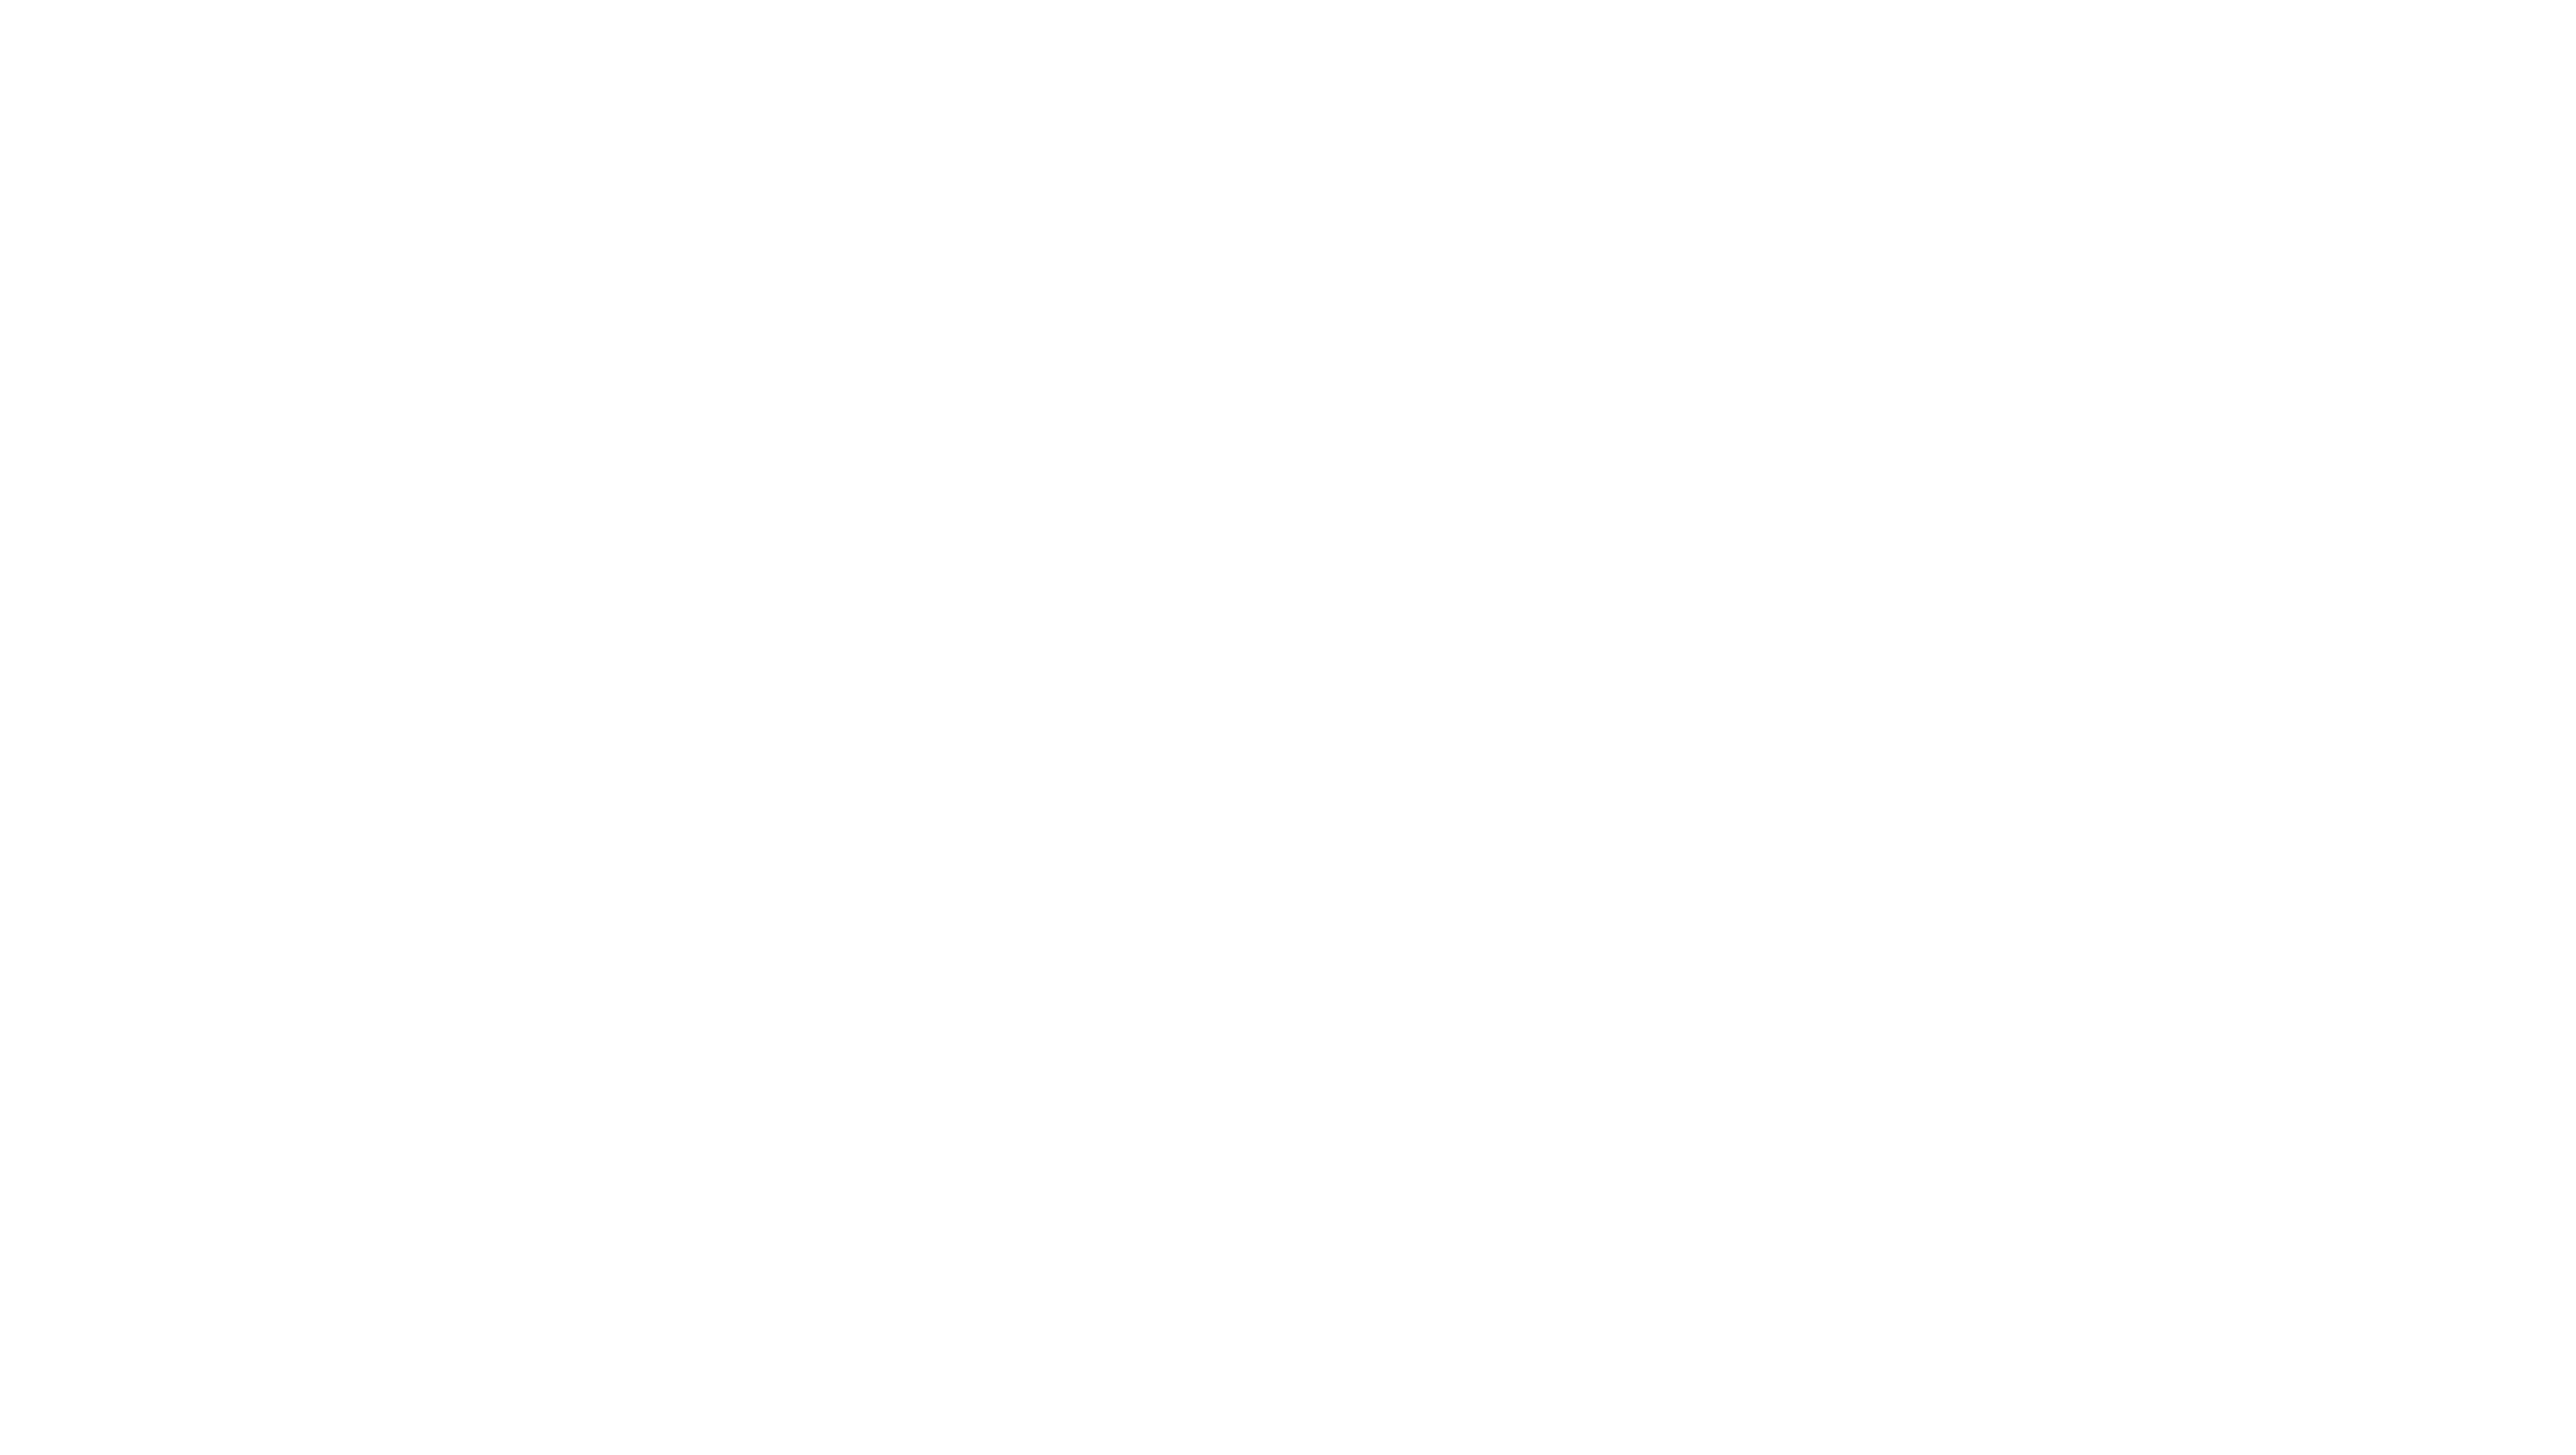

In [3]:
# ==============================================================================
# CELL 4: INFERENCE & ANALYSIS (EVALUATE 20K SNAPSHOT)
# ==============================================================================
import os
import glob
import deeplabcut
import yaml
import tensorflow as tf

WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
VIDEO_PATH = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4'
PROJECT_NAME = 'EagleRay_Top'

# --- 1. RECOVER PROJECT ---
found_projects = glob.glob(os.path.join(WORKING_DIR, f'{PROJECT_NAME}_Base-Dev-*', 'config.yaml'))
if not found_projects:
    raise FileNotFoundError("❌ Project config not found.")
base_cfg_path = found_projects[0]
proj_dir = os.path.dirname(base_cfg_path)
print(f"✅ Recovered project config: {base_cfg_path}")

# --- 2. VRAM CONFIG ---
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# --- 3. PATCH INFERENCE FOR 4K ---
print("🔧 Patching Inference Config for 4K VRAM survival...")
for p in glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', 'test', 'pose_cfg.yaml'), recursive=True):
    with open(p, 'r') as f:
        pose_cfg = yaml.safe_load(f)
    pose_cfg['global_scale'] = 0.25 
    with open(p, 'w') as f:
        yaml.dump(pose_cfg, f, default_flow_style=False)

# --- 4. EVALUATE & ANALYZE ---
print("📊 Evaluating Network Math (Pixel Error)...")
deeplabcut.evaluate_network(base_cfg_path, plotting=True)

print("\n🧠 Analyzing 4K Video and Generating MP4...")
deeplabcut.analyze_videos(base_cfg_path, [VIDEO_PATH], save_as_csv=True, batchsize=1)
deeplabcut.create_labeled_video(base_cfg_path, [VIDEO_PATH], draw_skeleton=True)
tf.keras.backend.clear_session()

print("\n✅ Analysis complete. Check the video directory for the labeled MP4.")

Attempting 1080p Pipeline, 4k is being problematic

In [4]:
import os

RAW_4K = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4'
OUT_1080 = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4'

print(f"🎬 Crunching 4K to 1080p...\nInput: {RAW_4K}")

# scale=1920:1080 downsamples the video
# -crf 18 maintains visually lossless quality
# -preset fast balances compression speed vs file size
exit_code = os.system(f'ffmpeg -hide_banner -loglevel warning -y -i "{RAW_4K}" -vf scale=1920:1080 -c:v libx264 -crf 18 -preset fast -c:a copy "{OUT_1080}"')

if exit_code == 0:
    print(f"✅ Conversion complete. \nNew Target: {OUT_1080}")
else:
    print("❌ FFmpeg conversion failed.")

🎬 Crunching 4K to 1080p...
Input: /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181.MP4


[swscaler @ 0x63bae1bab940] deprecated pixel format used, make sure you did set range correctly
[swscaler @ 0x63bae1c66d00] deprecated pixel format used, make sure you did set range correctly


✅ Conversion complete. 
New Target: /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4


    Last message repeated 2 times


2026-04-09 09:19:53.329110: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 09:19:53.390304: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-09 09:19:53.953763: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-09 09:19:59.087718: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 09:19:59.089713: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 09:19:59.091467: I tensorflow/compiler/xla/

🖼️ Downsampling extracted training frames to 1080p...


Config:
{'all_joints': [[0], [1], [2], [3], [4]],
 'all_joints_names': ['Snout',
                      'LeftWingtip',
                      'RightWingtip',
                      'TailBase',
                      'TailTip'],
 'alpha_r': 0.02,
 'apply_prob': 0.5,
 'batch_size': 1,
 'contrast': {'clahe': True,
              'claheratio': 0.1,
              'histeq': True,
              'histeqratio': 0.1},
 'convolution': {'edge': False,
                 'emboss': {'alpha': [0.0, 1.0], 'strength': [0.5, 1.5]},
                 'embossratio': 0.1,
                 'sharpen': False,
                 'sharpenratio': 0.3},
 'crop_pad': 0,
 'cropratio': 0.4,
 'dataset': 'training-datasets/iteration-0/UnaugmentedDataSet_EagleRay_Top_BaseApr8/EagleRay_Top_Base_Dev95shuffle1.mat',
 'dataset_type': 'default',
 'decay_steps': 30000,
 'deterministic': False,
 'display_iters': 1000,
 'fg_fraction': 0.25,
 'global_scale': 0.8,
 'init_weights': '/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packa

...

2026-04-09 11:40:09.144402: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 11:40:09.151769: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 11:40:09.155610: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Starting to analyze %  /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4
Loading  /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4
Duration of video [s]:  421.39 , recorded with  29.97 fps!
Overall # of frames:  12629  found with (before cropping) frame dimensions:  1920 1080
Starting to extract posture


  0%|          | 0/12629 [00:00<?, ?it/s]2026-04-09 11:40:13.583051: E tensorflow/compiler/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:306] gpu_async_0 cuMemAllocAsync failed to allocate 7242020304 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 1427898368/8220901376
2026-04-09 11:40:13.583071: E tensorflow/compiler/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:311] Stats: Limit:                      6376456192
InUse:                       253174380
MaxInUse:                   4348488612
NumAllocs:                    68343962
MaxAllocSize:               2874984848
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2026-04-09 11:40:13.583096: E tensorflow/compiler/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:63] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2026-04-09 11:40:13.5831

Saving results in /mnt/Data/Projects/cloud_deployment/videos/SER...
Saving csv poses!
The videos are analyzed. Now your research can truly start! 
 You can create labeled videos with 'create_labeled_video'
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.
Starting to process video: /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4
Loading /mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4 and data.
Duration of video [s]: 421.39, recorded with 29.97 fps!
Overall # of frames: 12629 with cropped frame dimensions: 1920 1080
Generating frames and creating video.


100%|██████████| 12629/12629 [03:01<00:00, 69.53it/s]


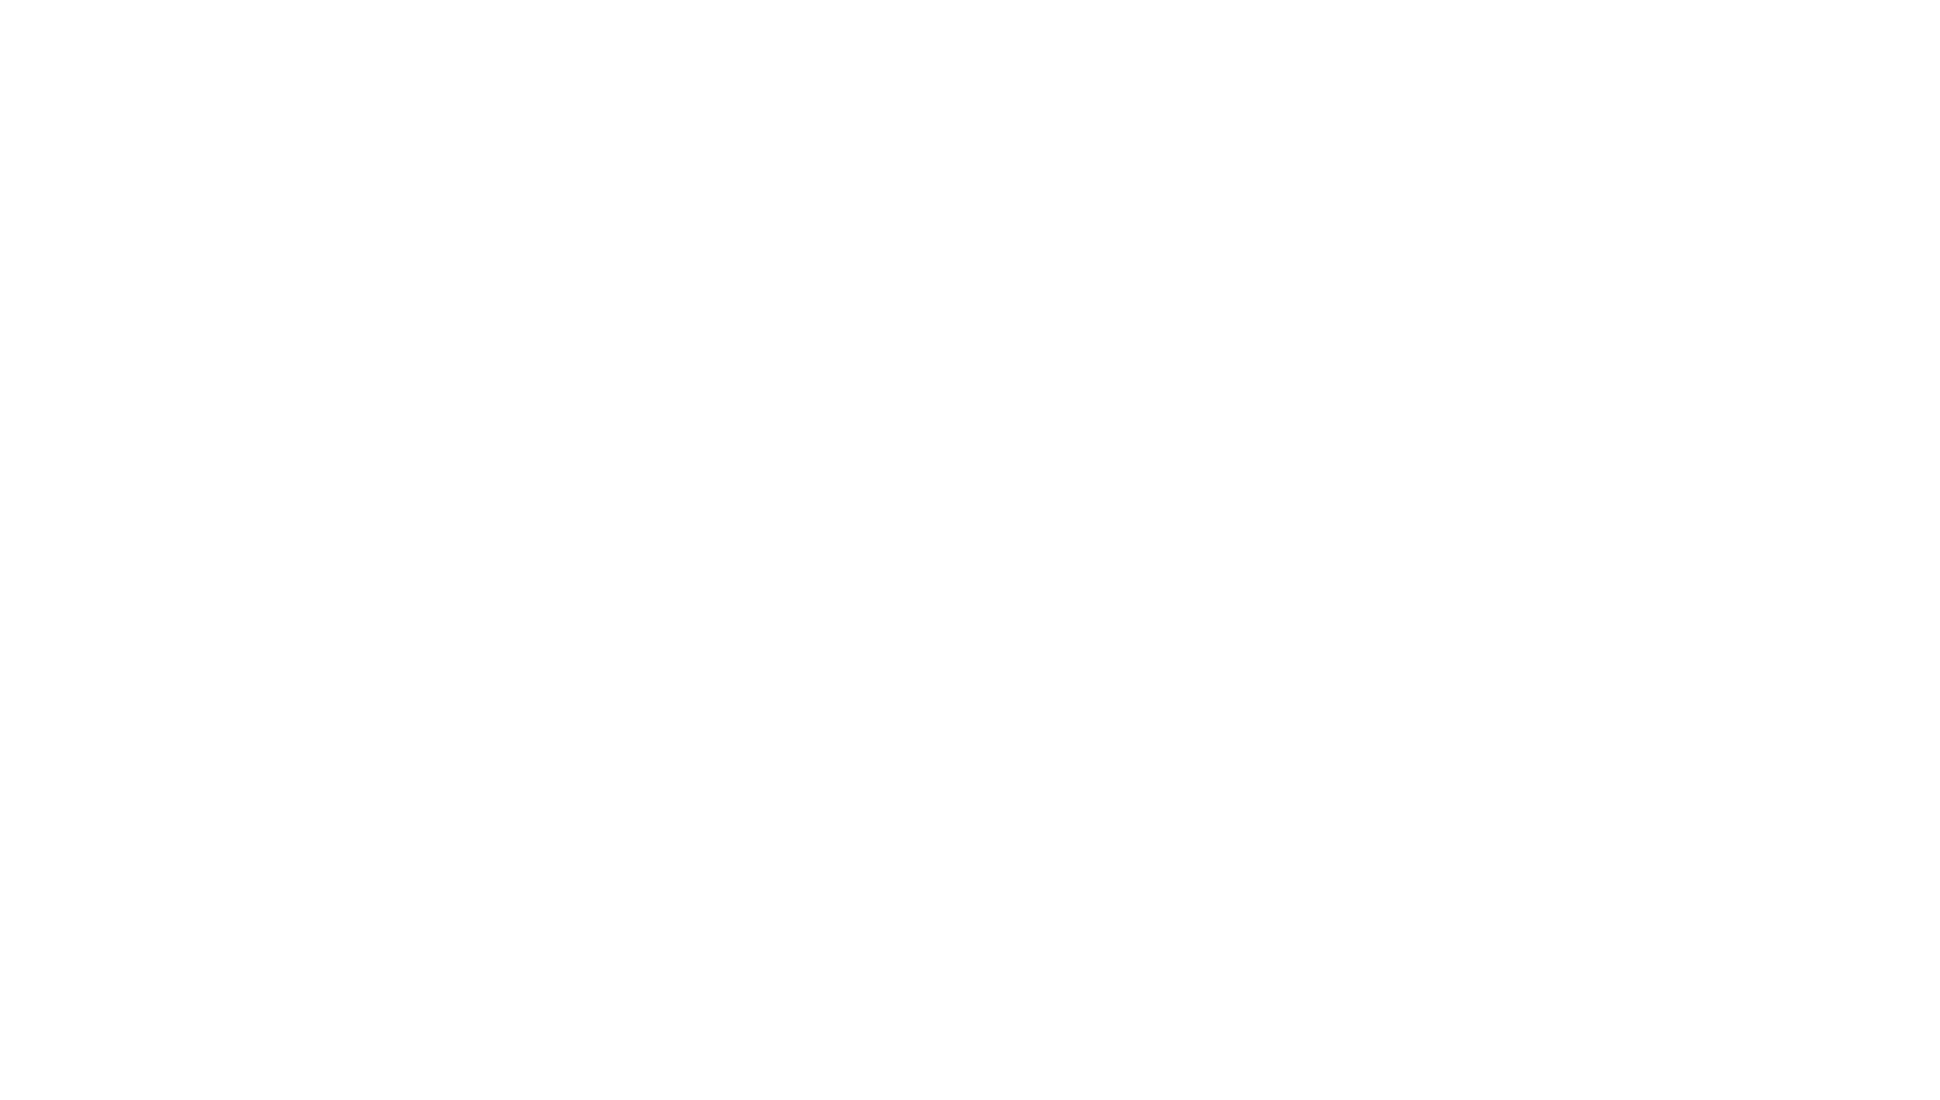

In [1]:
# ==============================================================================
# 1080p from 4k CONVERSION PIPELINE: RESIZE, PARSE, TRAIN, & ANALYZE
# ==============================================================================
import os
import glob
import cv2
import pandas as pd
import numpy as np
import json
import yaml
import tensorflow as tf
import deeplabcut

# --- 1. GLOBALS & PATHS ---
WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/AprilProjects/'
VIDEO_1080P = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080p.MP4'
PROJECT_NAME = 'EagleRay_Top'
BODYPARTS = ['Snout', 'LeftWingtip', 'RightWingtip', 'TailBase', 'TailTip'] 
CSV_EXPORT = '/mnt/Data/Projects/cloud_deployment/AprilProjects/EagleRay_Top_Base-Dev-2026-04-08/labeled-data/Fem1_releasedtp_20260401_GX010181/project-16-at-2026-04-08-12-53-79818071.csv'

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# --- 2. RECOVER PROJECT ---
found_projects = glob.glob(os.path.join(WORKING_DIR, f'{PROJECT_NAME}_Base-Dev-*', 'config.yaml'))
if not found_projects: raise FileNotFoundError("❌ Project config not found.")
base_cfg_path = found_projects[0]
proj_dir = os.path.dirname(base_cfg_path)
video_folder = os.path.splitext(os.path.basename(VIDEO_1080P.replace('_1080p', '')))[0]

with open(base_cfg_path, 'r') as f:
    cfg = yaml.safe_load(f)
exact_scorer = cfg.get('scorer', 'Dev')

# --- 3. DOWNSAMPLE EXTRACTED FRAMES TO 1080P ---
print("🖼️ Downsampling extracted training frames to 1080p...")
actual_img_dir = os.path.join(proj_dir, 'labeled-data', video_folder)
physical_files = [f for f in os.listdir(actual_img_dir) if f.endswith('.png')]

for f in physical_files:
    img_path = os.path.join(actual_img_dir, f)
    img = cv2.imread(img_path)
    if img is not None and img.shape[1] > 1920:
        resized = cv2.resize(img, (1920, 1080), interpolation=cv2.INTER_AREA)
        cv2.imwrite(img_path, resized)

# Map physical files
file_map = {int(''.join(filter(str.isdigit, f))): f for f in physical_files if f.startswith('img')}

# --- 4. 1080P PARSER ---
print("⚙️ Parsing Label Studio CSV for 1080p scaling...")
df_ls = pd.read_csv(CSV_EXPORT)

json_col = next((col for col in ['label', 'annotation', 'keypointlabels'] if col in df_ls.columns), None)
if not json_col:
    raise ValueError(f"❌ Could not find JSON column in CSV. Found headers: {list(df_ls.columns)}")

data_dict = {}
valid_points_found = 0

for idx, row in df_ls.iterrows():
    labels_str = row.get(json_col, '')
    img_path_raw = str(row.get('image', ''))
    
    fname_raw = os.path.basename(img_path_raw).split('-')[-1] if '-' in img_path_raw else os.path.basename(img_path_raw)
    frame_num = int(''.join(filter(str.isdigit, fname_raw)))
    fname = file_map.get(frame_num, fname_raw)
        
    rel_path = f"labeled-data/{video_folder}/{fname}"
    frame_data = {'image': rel_path}
    
    for bp in BODYPARTS:
        frame_data[f'{bp}_x'] = np.nan
        frame_data[f'{bp}_y'] = np.nan
        
    if pd.notna(labels_str) and isinstance(labels_str, str):
        try:
            labels = json.loads(labels_str)
            if isinstance(labels, list) and len(labels) > 0 and 'result' in labels[0]:
                labels = labels[0]['result']
                
            for label in labels:
                val = label.get('value', label) 
                if 'keypointlabels' in val and len(val['keypointlabels']) > 0:
                    bp = val['keypointlabels'][0]
                    if bp in BODYPARTS:
                        # Hardcoded 1080p multiplier
                        frame_data[f'{bp}_x'] = (val['x'] * 1920) / 100.0
                        frame_data[f'{bp}_y'] = (val['y'] * 1080) / 100.0
                        valid_points_found += 1
        except json.JSONDecodeError:
            pass
            
    if video_folder not in data_dict:
        data_dict[video_folder] = []
    data_dict[video_folder].append(frame_data)

print(f"📊 Extracted {len(data_dict.get(video_folder, []))} rows. Total valid coordinates found: {valid_points_found}")

# Build HDF5
df_video = pd.DataFrame(data_dict[video_folder]).set_index('image')
multi_cols = pd.MultiIndex.from_product([[exact_scorer], BODYPARTS, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])

final_data = [df_video[f'{bp}_{coord}'] for bp in BODYPARTS for coord in ['x', 'y']]
df_final = pd.concat(final_data, axis=1)
df_final.columns = multi_cols

out_dir = os.path.join(proj_dir, 'labeled-data', video_folder)
df_final.to_hdf(os.path.join(out_dir, f'CollectedData_{exact_scorer}.h5'), key='df_with_missing', mode='w')
df_final.to_csv(os.path.join(out_dir, f'CollectedData_{exact_scorer}.csv'))

# --- 5. BUILD & PATCH ---
print("\n🧹 Sweeping old data...")
os.system(f"rm -rf {proj_dir}/training-datasets/*")
os.system(f"rm -rf {proj_dir}/dlc-models/*")

# Revert to ResNet-50
cfg['default_net_type'] = 'resnet_50'
with open(base_cfg_path, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

deeplabcut.create_training_dataset(base_cfg_path, net_type='resnet_50')

print("🔧 Patching Dataloader...")
pose_configs = glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True)

for p in pose_configs:
    with open(p, 'r') as f:
        pose_cfg = yaml.safe_load(f)
        
    pose_cfg['dataset_type'] = 'default' 
    pose_cfg['batch_size'] = 1 # 1080p allows slightly larger batches
    pose_cfg['global_scale'] = 0.8
        
    with open(p, 'w') as f:
        yaml.dump(pose_cfg, f, default_flow_style=False)

# --- 6. TRAIN ---
print("🔥 PHASE 1: Running 5-iteration warmup...")
deeplabcut.train_network(base_cfg_path, maxiters=5, displayiters=1, saveiters=5, allow_growth=True) 

print("\n🚀 PHASE 2: Resuming ResNet-50 training on 1080p frames...")
deeplabcut.train_network(base_cfg_path, maxiters=50000, displayiters=1000, saveiters=10000, allow_growth=True) 

# --- 7. INFERENCE ---
for p in glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', 'test', 'pose_cfg.yaml'), recursive=True):
    with open(p, 'r') as f:
        pose_cfg = yaml.safe_load(f)
    pose_cfg['global_scale'] = 0.8
    with open(p, 'w') as f:
        yaml.dump(pose_cfg, f, default_flow_style=False)

print("\n📊 Evaluating Network...")
deeplabcut.evaluate_network(base_cfg_path, plotting=True)

print("\n🧠 Analyzing 1080p Video...")
deeplabcut.analyze_videos(base_cfg_path, [VIDEO_1080P], save_as_csv=True, batchsize=2)
deeplabcut.create_labeled_video(base_cfg_path, [VIDEO_1080P], draw_skeleton=True)
tf.keras.backend.clear_session()

In [ ]:
# ==============================================================================
# ML KINEMATIC IMPUTATION & PLOTTING PIPELINE
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from scipy.signal import savgol_filter

# --- 1. CONFIG & DATA LOAD ---
BASE_CSV = '/mnt/Data/Projects/cloud_deployment/videos/SER/Fem1_releasedtp_20260401_GX010181_1080pDLC_resnet50_EagleRay_Top_BaseApr8shuffle1_50000.csv'
OUT_CSV = BASE_CSV.replace('.csv', '_imputed.csv')
FPS = 30 # Assuming standard 30fps GoPro/Camera footage
PIXELS_PER_CM = 15 # Adjust this calibration metric based on your tank size

print("⚙️ Loading tracking data...")
df = pd.read_csv(BASE_CSV, header=[0, 1, 2], index_col=0)
scorer = df.columns.get_level_values(0)[0]

# --- 2. AMPUTATE THE TAILTIP ---
if 'TailTip' in df.columns.get_level_values(1):
    df.drop('TailTip', axis=1, level=1, inplace=True)
    print("🔪 Amputated TailTip track.")

bodyparts = ['Snout', 'LeftWingtip', 'RightWingtip', 'TailBase']
anchors = ['LeftWingtip', 'RightWingtip', 'TailBase']

# --- 3. THE PURGE (Filter out garbage) ---
print("🧹 Purging low confidence and teleporting frames...")
for bp in bodyparts:
    # 1. Confidence filter
    bad_conf = df[scorer, bp, 'likelihood'] < 0.6
    df.loc[bad_conf, (scorer, bp, 'x')] = np.nan
    df.loc[bad_conf, (scorer, bp, 'y')] = np.nan
    
    # 2. Velocity filter (Teleportation prevention)
    dist = np.sqrt(df[scorer, bp, 'x'].diff()**2 + df[scorer, bp, 'y'].diff()**2)
    jumps = dist > 50
    df.loc[jumps, (scorer, bp, 'x')] = np.nan
    df.loc[jumps, (scorer, bp, 'y')] = np.nan

# --- 4. TEMPORAL ANCHORING ---
# We use pchip (Piecewise Cubic Hermite Interpolating Polynomial) 
# to fill small gaps in the highly reliable anchor points first
print("⚓ Interpolating structural anchors...")
for bp in anchors:
    df[scorer, bp, 'x'] = df[scorer, bp, 'x'].interpolate(method='pchip', limit_direction='both')
    df[scorer, bp, 'y'] = df[scorer, bp, 'y'].interpolate(method='pchip', limit_direction='both')

# --- 5. THE ML GEOMETRIC RECONSTRUCTION ---
print("🧠 Training Regressor on Eagle Ray morphology...")
# Find "Gold Standard" frames where the Snout AND all anchors are perfectly visible
gold_mask = df[scorer, 'Snout', 'x'].notna() & df[scorer, anchors[0], 'x'].notna()

# X Features: [LeftWing_x, LeftWing_y, RightWing_x, RightWing_y, TailBase_x, TailBase_y]
X = pd.concat([df[scorer, bp][['x', 'y']] for bp in anchors], axis=1).values
# Y Targets: [Snout_x, Snout_y]
Y = df[scorer, 'Snout'][['x', 'y']].values

# Train the model on the Gold Standard geometry
X_train = X[gold_mask]
Y_train = Y[gold_mask]

regressor = Ridge(alpha=1.0)
regressor.fit(X_train, Y_train)
print(f"✅ Morphological model trained. R^2 Score: {regressor.score(X_train, Y_train):.4f}")

# Reconstruct the missing Snout points based on the anchors
missing_snout_mask = df[scorer, 'Snout', 'x'].isna()
if missing_snout_mask.sum() > 0:
    predicted_snout = regressor.predict(X[missing_snout_mask])
    df.loc[missing_snout_mask, (scorer, 'Snout', 'x')] = predicted_snout[:, 0]
    df.loc[missing_snout_mask, (scorer, 'Snout', 'y')] = predicted_snout[:, 1]
    print(f"🪄 Imputed {missing_snout_mask.sum()} missing Snout frames via ML geometry.")

# Final temporal cleanup for any remaining nan edges
df.interpolate(method='pchip', limit_direction='both', inplace=True)

# --- 6. THE BIOLOGICAL SMOOTHER (Savitzky-Golay) ---
print("🌊 Applying fluid biological kinematics (Savitzky-Golay)...")
# Window=15 frames (0.5s), Poly=3 (allows smooth curves without over-flattening)
for bp in bodyparts:
    df[scorer, bp, 'x'] = savgol_filter(df[scorer, bp, 'x'], window_length=15, polyorder=3)
    df[scorer, bp, 'y'] = savgol_filter(df[scorer, bp, 'y'], window_length=15, polyorder=3)

# Save the Imputed Dataset
df.to_csv(OUT_CSV)
print(f"💾 Saved clean kinematics to {OUT_CSV}")

# --- 7. KINEMATIC PLOTTING ---
print("📊 Generating Kinematics Plots...")

# Calculate Center of Mass (Average of all 4 points)
com_x = df.xs('x', level=2, axis=1).mean(axis=1)
com_y = df.xs('y', level=2, axis=1).mean(axis=1)

# Calculate Velocity (cm/s)
dx = com_x.diff()
dy = com_y.diff()
distance_px = np.sqrt(dx**2 + dy**2)
velocity_cm_s = (distance_px / PIXELS_PER_CM) * FPS

time_sec = np.arange(len(df)) / FPS

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(16, 10))

# Plot 1: Tank Trajectory
ax1 = plt.subplot(2, 2, (1, 3))
sns.kdeplot(x=com_x, y=com_y, cmap="mako", fill=True, thresh=0.05, alpha=0.5, ax=ax1)
ax1.plot(com_x, com_y, color='red', linewidth=1.5, alpha=0.8, label="Ray Center of Mass")
ax1.set_title("Eagle Ray Tank Utilization & Trajectory", fontsize=14, fontweight='bold')
ax1.set_xlabel("X Pixel Coordinate")
ax1.set_ylabel("Y Pixel Coordinate")
ax1.invert_yaxis() # Match video coordinate system (0,0 is top left)
ax1.legend()

# Plot 2: Velocity Profile
ax2 = plt.subplot(2, 2, 2)
ax2.plot(time_sec, velocity_cm_s, color='darkorange', linewidth=1.5)
ax2.set_title("Kinematic Velocity Profile", fontsize=14, fontweight='bold')
ax2.set_xlabel("Time (Seconds)")
ax2.set_ylabel("Velocity (cm / s)")
ax2.axhline(velocity_cm_s.mean(), color='black', linestyle='--', label=f'Mean Velocity ({velocity_cm_s.mean():.1f} cm/s)')
ax2.legend()

# Plot 3: ML Imputation Verification (Snout vs Anchors X-Axis over time)
ax3 = plt.subplot(2, 2, 4)
ax3.plot(time_sec, df[scorer, 'Snout', 'x'], label="Snout (Imputed)", color='blue', alpha=0.8)
ax3.plot(time_sec, df[scorer, 'TailBase', 'x'], label="TailBase (Anchor)", color='green', alpha=0.6)
ax3.set_title("Longitudinal Axis Tracking (X-Coords)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Time (Seconds)")
ax3.set_ylabel("X Position (Pixels)")
ax3.legend()

plt.tight_layout()
plt.savefig('EagleRay_Kinematics_Report.png', dpi=300)
plt.show()
print("✅ Done.")

⚙️ Loading tracking data...


FileNotFoundError: [Errno 2] No such file or directory: 'Fem1_releasedtp_20260401_GX010181_1080pDLC_resnet50_EagleRay_Top_BaseApr8shuffle1_50000.csv'